# PASSO 3 - Treinamento de Modelo (Random Forest)
Nesse passo, vamos treinar modelos Random Forest para cada traço de personalidade MBTI.

## 0. Setup
Importar os pacotes necessários para rodar o resto do código.

In [1]:
from pathlib import Path
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
from pipeline.smote_oversampling import SMOTEOversampler
from pipeline.utils.extras import divide_mbti
from pipeline.machine_learning_algorithms.random_forest import RandomForestClassifier

# Tamanho do subset humano original no passo 2 (antes da augmentação por SLM).
# Validado em cada experimento "base" para garantir que o fatiamento [:N_HUMAN_POSTS]
# realmente corresponde aos posts humanos e não inclui amostras augmentadas.
N_HUMAN_POSTS = 6940
DATA_DIR = Path("data")
TRAIN_DIR = DATA_DIR / "train_datasets"
TEST_DIR = DATA_DIR / "test_datasets"
MODELS_DIR = Path("models/random_forest")
RF_PARAMS = dict(
    param_grid={'n_estimators': [50, 100], 'max_depth': [10, 20]},
    cv=2,
    n_jobs=2,
    random_state=42,
)

def load_train_test(embedding):
    """Carrega x_train/x_test (para um embedding) e y_train/y_test (comuns a todos)."""
    x_train = pd.read_pickle(TRAIN_DIR / f"x_train_{embedding}.pkl")
    x_test = pd.read_pickle(TEST_DIR / f"x_test_{embedding}.pkl")
    y_train = pd.Series(pd.read_pickle(TRAIN_DIR / "y_train.pkl"))
    y_test = pd.Series(pd.read_pickle(TEST_DIR / "y_test.pkl"))
    return x_train, x_test, y_train, y_test

def save_models(clf, label):
    """Salva os 4 submodelos (um por traço MBTI) com sufixo `label`."""
    for key, model in clf.models.items():
        path = MODELS_DIR / f"{key}_{label}.pkl"
        path.parent.mkdir(parents=True, exist_ok=True)
        joblib.dump(model, path)
        print(f"Salvo: {path}")

def run_experiment(embedding, label, *, use_smote=True, human_only=False):
    """Carrega dados, (opcionalmente) aplica SMOTE, treina, avalia e salva os modelos.

    - `human_only=True`: restringe o treino aos posts humanos originais (sem augmentação SLM).
    - `use_smote=False`: não aplica oversampling (baseline sem SMOTE).
    Retorna o classificador treinado (predições ficam disponíveis via clf.predict).

    Observação: o Random Forest executa um GridSearchCV por traço (f1_macro, 2-fold)
    durante o `fit`; o melhor estimador de cada traço é guardado em clf.models[dim]."""
    x_train, x_test, y_train, y_test = load_train_test(embedding)

    if human_only:
        assert len(x_train) >= N_HUMAN_POSTS, (
            f"x_train ({len(x_train)}) menor que N_HUMAN_POSTS ({N_HUMAN_POSTS}); "
            "verifique a ordem de concatenação no passo 2."
        )
        x_train = x_train[:N_HUMAN_POSTS]
        y_train = y_train[:N_HUMAN_POSTS]

    if use_smote:
        x_train, y_train = SMOTEOversampler(random_state=42).fit_resample(x_train, y_train)

    y_train_4cols = divide_mbti(y_train)
    y_test_4cols = divide_mbti(y_test.reset_index(drop=True))

    clf = RandomForestClassifier(**RF_PARAMS)
    clf.fit(x_train, y_train_4cols)
    clf.evaluate(x_test, y_test_4cols)
    save_models(clf, label)
    return clf


## 1. Baseline
Treina apenas com os posts humanos originais, sem aplicação de técnicas de balanceamento de classes. Serve como parâmetro de controle para avaliar o ganho das otimizações posteriores.

#### TF-IDF

In [2]:
tfidf_baseline = run_experiment('tfidf', 'tfidf_baseline', use_smote=False, human_only=True)

Starting training process...
 -> Training model for I_E...
 -> Training model for N_S...
 -> Training model for T_F...
 -> Training model for J_P...
All 4 models trained successfully! ✅

Evaluation for dimension: I_E
Accuracy: 0.7689

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       401
           1       0.77      1.00      0.87      1334

    accuracy                           0.77      1735
   macro avg       0.38      0.50      0.43      1735
weighted avg       0.59      0.77      0.67      1735


Evaluation for dimension: N_S
Accuracy: 0.8617

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       240
           1       0.86      1.00      0.93      1495

    accuracy                           0.86      1735
   macro avg       0.43      0.50      0.46      1735
weighted avg       0.74      0.86      0.80      1735


Evaluation for dimension: T_F
Accuracy: 0.7614

             

#### Word2Vec

In [3]:
w2v_baseline = run_experiment('w2v', 'w2v_baseline', use_smote=False, human_only=True)

Starting training process...
 -> Training model for I_E...
 -> Training model for N_S...
 -> Training model for T_F...
 -> Training model for J_P...
All 4 models trained successfully! ✅

Evaluation for dimension: I_E
Accuracy: 0.7556

              precision    recall  f1-score   support

           0       0.33      0.05      0.09       401
           1       0.77      0.97      0.86      1334

    accuracy                           0.76      1735
   macro avg       0.55      0.51      0.48      1735
weighted avg       0.67      0.76      0.68      1735


Evaluation for dimension: N_S
Accuracy: 0.8565

              precision    recall  f1-score   support

           0       0.20      0.01      0.02       240
           1       0.86      0.99      0.92      1495

    accuracy                           0.86      1735
   macro avg       0.53      0.50      0.47      1735
weighted avg       0.77      0.86      0.80      1735


Evaluation for dimension: T_F
Accuracy: 0.7401

             

## 2. Baseline + SMOTE
Treina com um over-sampling SMOTE dos dados originais. Gerando amostras sintéticas baseadas nas classes minoritárias, visando reduzir o viés do modelo.

#### TF-IDF

In [4]:
tfidf_smote = run_experiment('tfidf', 'tfidf_smote', use_smote=True, human_only=True)

Original dataset shape: X=(6940, 10000), y=(6940,)
Resampled dataset shape: X=(23456, 10000), y=(23456,)
Starting training process...
 -> Training model for I_E...
 -> Training model for N_S...
 -> Training model for T_F...
 -> Training model for J_P...
All 4 models trained successfully! ✅

Evaluation for dimension: I_E
Accuracy: 0.7764

              precision    recall  f1-score   support

           0       0.88      0.04      0.07       401
           1       0.78      1.00      0.87      1334

    accuracy                           0.78      1735
   macro avg       0.83      0.52      0.47      1735
weighted avg       0.80      0.78      0.69      1735


Evaluation for dimension: N_S
Accuracy: 0.8617

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       240
           1       0.86      1.00      0.93      1495

    accuracy                           0.86      1735
   macro avg       0.43      0.50      0.46      1735
weighted avg

#### Word2Vec

In [5]:
w2v_smote = run_experiment('w2v', 'w2v_smote', use_smote=True, human_only=True)

Original dataset shape: X=(6940, 500), y=(6940,)
Resampled dataset shape: X=(23456, 500), y=(23456,)
Starting training process...
 -> Training model for I_E...
 -> Training model for N_S...
 -> Training model for T_F...
 -> Training model for J_P...
All 4 models trained successfully! ✅

Evaluation for dimension: I_E
Accuracy: 0.7251

              precision    recall  f1-score   support

           0       0.36      0.24      0.29       401
           1       0.79      0.87      0.83      1334

    accuracy                           0.73      1735
   macro avg       0.58      0.56      0.56      1735
weighted avg       0.69      0.73      0.71      1735


Evaluation for dimension: N_S
Accuracy: 0.8427

              precision    recall  f1-score   support

           0       0.32      0.12      0.18       240
           1       0.87      0.96      0.91      1495

    accuracy                           0.84      1735
   macro avg       0.60      0.54      0.54      1735
weighted avg    

## 3. Baseline + SMOTE + SLM
Treina com um over-sampling e um augmentation de SLM (qwen) dos dados originais. O objetivo é testar se a variabilidade introduzida pela IA melhora a capacidade de generalização do modelo.

#### TF-IDF

In [6]:
tfidf_aug = run_experiment('tfidf', 'tfidf_aug', use_smote=True, human_only=False)

Original dataset shape: X=(9322, 10000), y=(9322,)
Resampled dataset shape: X=(23456, 10000), y=(23456,)
Starting training process...
 -> Training model for I_E...
 -> Training model for N_S...
 -> Training model for T_F...
 -> Training model for J_P...
All 4 models trained successfully! ✅

Evaluation for dimension: I_E
Accuracy: 0.7706

              precision    recall  f1-score   support

           0       0.59      0.02      0.05       401
           1       0.77      0.99      0.87      1334

    accuracy                           0.77      1735
   macro avg       0.68      0.51      0.46      1735
weighted avg       0.73      0.77      0.68      1735


Evaluation for dimension: N_S
Accuracy: 0.8617

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       240
           1       0.86      1.00      0.93      1495

    accuracy                           0.86      1735
   macro avg       0.43      0.50      0.46      1735
weighted avg

#### Word2Vec

In [7]:
w2v_aug = run_experiment('w2v', 'w2v_aug', use_smote=True, human_only=False)

Original dataset shape: X=(9322, 500), y=(9322,)
Resampled dataset shape: X=(23456, 500), y=(23456,)
Starting training process...
 -> Training model for I_E...
 -> Training model for N_S...
 -> Training model for T_F...
 -> Training model for J_P...
All 4 models trained successfully! ✅

Evaluation for dimension: I_E
Accuracy: 0.7401

              precision    recall  f1-score   support

           0       0.35      0.15      0.21       401
           1       0.78      0.92      0.84      1334

    accuracy                           0.74      1735
   macro avg       0.57      0.53      0.53      1735
weighted avg       0.68      0.74      0.70      1735


Evaluation for dimension: N_S
Accuracy: 0.8542

              precision    recall  f1-score   support

           0       0.33      0.05      0.09       240
           1       0.87      0.98      0.92      1495

    accuracy                           0.85      1735
   macro avg       0.60      0.52      0.51      1735
weighted avg    

## 4. Análise Comparativa
Avaliação da performance preditiva dos modelos, comparando os resultados das predições de cada experimento.

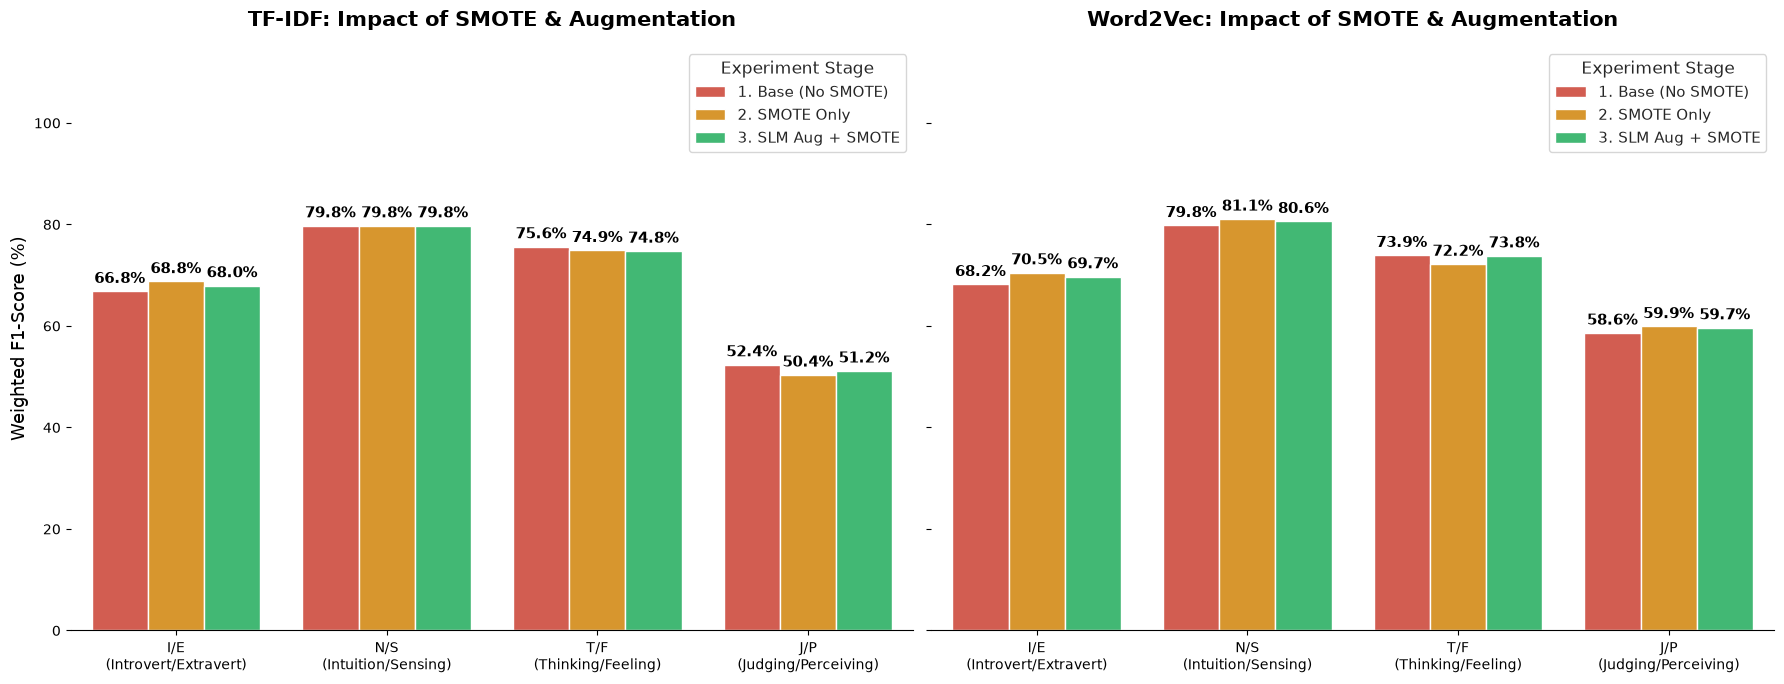

In [8]:
x_test_tfidf = pd.read_pickle(TEST_DIR / "x_test_tfidf.pkl")
x_test_w2v = pd.read_pickle(TEST_DIR / "x_test_w2v.pkl")
y_test_raw = pd.Series(pd.read_pickle(TEST_DIR / "y_test.pkl"))
y_test_4cols = divide_mbti(y_test_raw)

pred_tfidf_base = tfidf_baseline.predict(x_test_tfidf)
pred_w2v_base = w2v_baseline.predict(x_test_w2v)
pred_tfidf_smote = tfidf_smote.predict(x_test_tfidf)
pred_w2v_smote = w2v_smote.predict(x_test_w2v)
pred_tfidf_aug = tfidf_aug.predict(x_test_tfidf)
pred_w2v_aug = w2v_aug.predict(x_test_w2v)

colunas = ['I_E', 'N_S', 'T_F', 'J_P']
nomes_eixos = ['I/E\n(Introvert/Extravert)', 'N/S\n(Intuition/Sensing)',
               'T/F\n(Thinking/Feeling)', 'J/P\n(Judging/Perceiving)']

experiments = [
    ('1. Base (No SMOTE)', 'TF-IDF', pred_tfidf_base),
    ('2. SMOTE Only',      'TF-IDF', pred_tfidf_smote),
    ('3. SLM Aug + SMOTE', 'TF-IDF', pred_tfidf_aug),
    ('1. Base (No SMOTE)', 'Word2Vec', pred_w2v_base),
    ('2. SMOTE Only',      'Word2Vec', pred_w2v_smote),
    ('3. SLM Aug + SMOTE', 'Word2Vec', pred_w2v_aug),
]

dados = [
    {'Axis': nomes_eixos[i], 'F1 (%)': f1_score(y_test_4cols[col], pred[col], average='weighted') * 100,
     'Method': method, 'Embedding': emb}
    for method, emb, pred in experiments
    for i, col in enumerate(colunas)
]
df_plot = pd.DataFrame(dados)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
sns.set_theme(style="whitegrid")
paleta = ['#e74c3c', '#f39c12', '#2ecc71']

for ax, emb in zip(axes, ['TF-IDF', 'Word2Vec']):
    sns.barplot(data=df_plot[df_plot['Embedding'] == emb],
                x='Axis', y='F1 (%)', hue='Method', palette=paleta, ax=ax)
    ax.set_title(f"{emb}: Impact of SMOTE & Augmentation",
                 fontsize=15, fontweight='bold', pad=15)
    ax.set_ylim(0, 115)
    ax.set_xlabel("")
    if emb == 'TF-IDF':
        ax.set_ylabel("Weighted F1-Score (%)", fontsize=13)
    else:
        ax.set_ylabel("")
    for p in ax.patches:
        altura = p.get_height()
        if altura > 0:
            ax.annotate(f"{altura:.1f}%",
                        (p.get_x() + p.get_width() / 2., altura),
                        ha='center', va='baseline', fontsize=11,
                        fontweight='bold', color='black',
                        xytext=(0, 6), textcoords='offset points')
    ax.legend(title='Experiment Stage', fontsize='11', loc='upper right')

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()